# Kaggle PlayGround 2026年3月実施分


## Cassava Leaf Disease Classification

[https://www.kaggle.com/competitions/cassava-leaf-disease-classification/](https://www.kaggle.com/competitions/cassava-leaf-disease-classification/)

#### 今回の目的
* 単純なCNNモデル（SimpleCNN）をゼロから自作し、画像タスクの基礎を学ぶ
* 逆伝播の流れにおいて、Loss関数がどう「勾配（学習のヒント）」を生み出し、AIの重みを更新していくかの仕様を学ぶ
* クラス不均衡データの対応を学ぶ
* データ数の偏りを補正する「重み付け（$\alpha$）」の実装とペナルティを与える「Focal Loss（$\gamma$）」の数式を理解する



In [ ]:
pip -q install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 50.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'{device} を使用')

cuda を使用


In [ ]:
# APIトークンを設定
os.environ['KAGGLE_API_TOKEN'] = "KGAT_de99c63f5c523fecaac2558f696af973"

print("APIトークンのセットアップが完了しました！データのダウンロードを開始します...")

# コンペティションのデータを一括ダウンロード
!kaggle competitions download -c cassava-leaf-disease-classification

# データを解凍して専用のフォルダ（cassava-data）にまとめる
!unzip -q cassava-leaf-disease-classification.zip -d cassava-data

print("\nデータのダウンロードと解凍が完了しました！")

APIトークンのセットアップが完了しました！データのダウンロードを開始します...
100% 5.76G/5.76G [06:55<00:00, 14.9MB/s]


データのダウンロードと解凍が完了しました！


In [ ]:
# CSVファイルを読み込んで先頭5行を表示
df = pd.read_csv('./cassava-data/train.csv')
print(f"学習データの総数: {len(df)} 件\n")
print(df.head())

# 画像フォルダの中身を数える
image_files = os.listdir('./cassava-data/train_images')
print(f"\nダウンロードされた画像枚数: {len(image_files)} 枚")

学習データの総数: 21397 件

         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

ダウンロードされた画像枚数: 21397 枚


<b>病名と症状について</b>

<details>
<summary>0: Cassava Bacterial Blight (CBB: 細菌性胴枯病)</summary>

**症状**  
- 葉の黒色斑点、葉の先端が枯れる  
- 若い葉や茎に水浸状の病斑  
- 最終的に植物全体が枯れることも  

**影響**  
- 葉が落ちて光合成低下  
- 根の生育も阻害、収量減少  

**特徴**  
- 高湿度で広がりやすい  
- 伝染力が強く、農家で管理が大変  

</details>

<details>
<summary>1: Cassava Brown Streak Disease (CBSD: 褐条病)</summary>

**症状**  
- 葉の黄化や黄色い斑点  
- 茎に茶色の縦条  
- 根に内部褐変（食用根が腐ったようになる）  

**影響**  
- 根の品質低下 → 食用・市場価値が減る  
- 収量低下  

**特徴**  
- 根に症状が出るのが特徴的  
- アフリカ東部で特に被害が深刻  

</details>

<details>
<summary>2: Cassava Green Mottle (CGM: 緑斑モザイク病)</summary>

**症状**  
- 葉に明暗のモザイク状の斑点（緑と薄緑のまだら模様）  
- 若い葉に特に症状が出やすい  

**影響**  
- 光合成効率低下 → 生育不良  
- 根の収量も減る  

**特徴**  
- 病気自体は軽度なこともあるが、複合感染すると深刻化  
- アフリカで最も広く被害がある病気  
- 白斑やモザイク模様が分かりやすく、葉の症状が典型的  

</details>

<details>
<summary>3: Cassava Mosaic Disease (CMD: モザイク病)</summary>

**症状**  
- 葉が縮れ、モザイク状の黄緑斑  
- 新葉が小さく変形  
- 根の発育不良  

**影響**  
- 葉の光合成低下 → 生育全体に影響  
- 収量が大幅に下がる  

**特徴**  
- アフリカで最も広く被害がある病気  
- 白斑やモザイク模様が分かりやすく、葉の症状が典型的  

</details>

<details>
<summary>4: Healthy (健康)</summary>

**症状**  
- 病気の症状なし  

**影響**  
- なし  

**特徴**  
- 葉は緑色で正常に光合成が行われている  
- 根も正常に肥大している  

</details>

#### 一時保存用

In [ ]:
from google.colab import files

In [ ]:
"""
from google.colab import drive
drive.mount('/content/drive')

# 保存先
save_dir = '/content/drive/MyDrive/Kaggle_Cassava/'
os.makedirs(save_dir, exist_ok=True)

# .pth ファイルで保存
save_path = os.path.join(save_dir, 'Cassava_simple_cnn_epoch5.pth')

# 保存
# model.state_dict() で重みだけを抽出
torch.save(model.state_dict(), save_path)
print('保存完了')

# 復元
model = SimpleCNN().to(device)

# ファイルパス
load_path = '/content/drive/MyDrive/Kaggle_Cassava/Cassava_simple_cnn_epoch5.pth'

# torch.load でファイルを読み込み、load_state_dict modelに重みを流す
model.load_state_dict(torch.load(load_path))

# ※もし推論（Grad-CAMなど）だけを行うなら、必ずテストモードにしておく
# model.eval()
"""

In [ ]:
# 学習状況を保存
save_path = '/content/my_simple_cnn_epoch5.pth'
torch.save(model.state_dict(), save_path)
print("ダウンロード開始")
files.download(save_path)

パソコンへのダウンロードを開始します...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. データの読み込みと分割（前回の再現）
df = pd.read_csv('./cassava-data/train.csv')
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# 2. Datasetクラスの定義
class CassavaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['image_id']
        label = self.dataframe.iloc[idx]['label']
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

# 3. 設計図（SimpleCNN）の定義
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 32 * 32, 512)
        self.fc2 = nn.Linear(512, num_classes)
    def forward (self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 4. モデルのインスタンス化と記憶の注入
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

print("保存した .pth ファイルをアップロードしてください。")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 記憶をロード
model.load_state_dict(torch.load(filename, map_location=device))
model.eval()
print(f"\n復元完了！ {filename} の状態から再開")

# 検証用データローダーの準備（Grad-CAM用）
test_transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])
val_dataset = CassavaDataset(val_df, './cassava-data/train_images', transform=test_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

保存した .pth ファイルをアップロードしてください。


Saving my_simple_cnn_epoch5.pth to my_simple_cnn_epoch5 (1).pth

★復元完了！ my_simple_cnn_epoch5 (1).pth の状態から再開します。


### シンプルCNNの実装
#### 畳み込みニューラルネットワーク実装の練習

In [ ]:
# csv 読み込み
df = pd.read_csv('./cassava-data/train.csv')

# Datasetクラス
class CassavaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['image_id']
        label = self.dataframe.iloc[idx]['label']
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, label

# 画像の加工ルール（256×256に揃えてTensorに変換）
my_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# DataLoaderの作成（バッチサイズを32に設定）
train_dataset = CassavaDataset(df, './cassava-data/train_images', transform=my_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #torch.Size([32, 3, 256, 256])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()

        # 1層目；入力チャンネル:3(RGB)、出力16、スコープ3×3
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

        # プーリング層 ：2×2で圧縮、サイズが縦横半分となる
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 2層目：入力チャンネル:16、出力32、スコープ3×3
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # 3層目：入力チャンネル:32、出力64、スコープ3×3
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # 全結合層：最終的にチャンネル数(64)×縦(32)×横(32)のデータが流れている
        self.fc1 = nn.Linear(in_features=64 * 32 * 32, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=num_classes) # 出力は5（病気4+健康1の5分類）

    def forward (self, x):
        # 実際にデータ(x)が流れていくルート（順伝播）を定義（畳み込み →　活性化関数(ReLu) → プーリング）
        # ReLu関数 f(x) = max(0, x)

        # 1層目：サイズ256×256　→ 128×128 に圧縮
        x = self.pool(F.relu(self.conv1(x)))

        # 2層目；サイズ：128×128 → 64×64に圧縮
        x = self.pool(F.relu(self.conv2(x)))

        # 3層目：サイズ64×64 → 32×32に圧縮
        x = self.pool(F.relu(self.conv3(x)))

        # 平坦化：立体的なデータ（64, 32, 32）を1列のベクトルにする
        x = x.view(-1, 64 * 32 * 32)

        # 全結合層：最終出力（5つに分類）
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# モデルを作成し、GPUに送る
model = SimpleCNN().to(device)
print('モデル作成完了')

モデル作成完了


特徴マップを可視化 


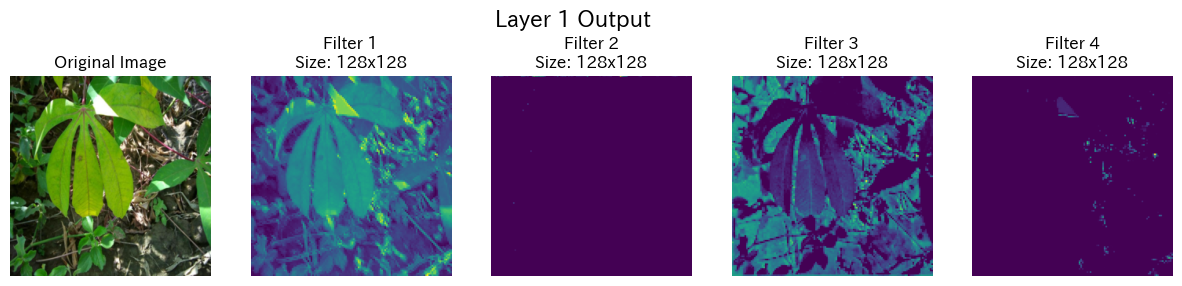

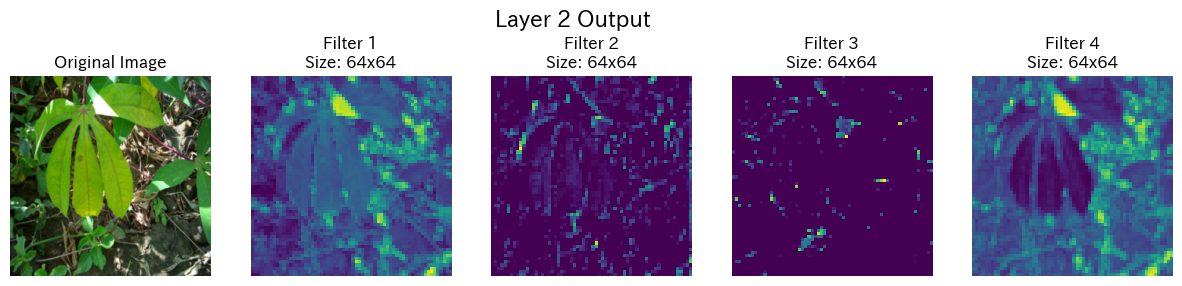

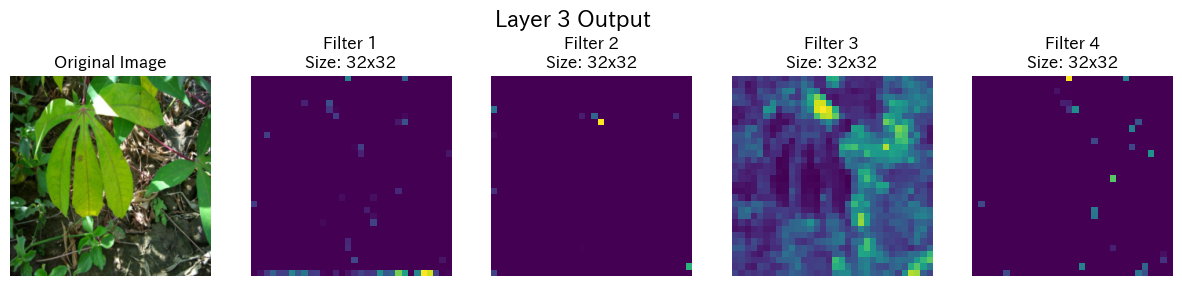

In [ ]:
# 各層で画像がどのように出力されているか確認

# DataLoaderから1バッチ（32枚）だけ画像を取り出し、最初の1枚をピックアップする
dataiter = iter(train_loader)
images, labels = next(dataiter)
single_image = images[0].unsqueeze(0).to(device) # 1枚だけを取り出し、[1, 3, 256, 256]の形にしてGPUへ

print("特徴マップを可視化 ")

# 1層ずつデータを通していく
model.eval() # テストモードにする

with torch.no_grad():
    # 1層目\
    out1 = model.pool(F.relu(model.conv1(single_image)))

    # 2層目
    out2 = model.pool(F.relu(model.conv2(out1)))

    # 3層目
    out3 = model.pool(F.relu(model.conv3(out2)))

# 結果を画像として表示
def show_feature_maps(original_img, feature_map, layer_num, num_maps_to_show=4):
    """
    original_img: 元の画像
    feature_map: 各層の出力データ
    layer_num: 何層目か
    num_maps_to_show: 何個のフィルター(チャンネル)を表示するか
    """
    # TensorからNumPy配列に変換（matplotlibで表示するため）
    # shapeは [1(枚), チャンネル数, 縦, 横] になっている
    maps = feature_map.squeeze(0).cpu().numpy()

    fig, axes = plt.subplots(1, num_maps_to_show + 1, figsize=(15, 3))

    # 1枚目に元の画像を表示
    orig = original_img.squeeze(0).cpu().permute(1, 2, 0).numpy()
    axes[0].imshow(orig)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # 2枚目以降に抽出された特徴マップを表示
    for i in range(num_maps_to_show):
        # i番目のチャンネル（フィルター）の画像を取り出す
        f_map = maps[i]
        axes[i+1].imshow(f_map, cmap='viridis')
        axes[i+1].set_title(f"Filter {i+1}\nSize: {f_map.shape[0]}x{f_map.shape[1]}")
        axes[i+1].axis('off')

    plt.suptitle(f"Layer {layer_num} Output", fontsize=16, y=1.05)
    plt.show()

# 4. 画像を出力
show_feature_maps(single_image, out1, layer_num=1)
show_feature_maps(single_image, out2, layer_num=2)
show_feature_maps(single_image, out3, layer_num=3)

In [ ]:
# 評価とモデル修正

# CrossEntropyLoss関数 L = -log(p)
criterion = nn.CrossEntropyLoss()

# Optimizerの設定（モデル内の全パラメータと修正歩幅lrを渡す）
optimizer = optim.AdamW(model.parameters(), lr=0.001) # 学習率0.001

# 学習
num_epochs = 3

for epoch in range(num_epochs):

    # DataLoderから32枚ずつデータを取得
    for batch_idx, (images, labels) in enumerate(train_loader):

        # 画像とラベルをGPUに送る
        images = images.to(device)
        labels = labels.to(device)

        # 学習ステップ
        optimizer.zero_grad()                # 準備（勾配リセット）
        outputs = model(images)              # 予測（順伝播）
        loss = criterion(outputs, labels)    # 評価（Lossの計算）
        loss.backward()                      # 原因の特定（誤差逆伝播）
        optimizer.step()                     # モデル修正（重みの更新）

        # 100バッチ（3200枚）ごとに現在のLossを表示
        if batch_idx % 100 == 0:
            print(f'Epch[{epoch+1}/{num_epochs}], Batch[{batch_idx}/{len(train_loader)}, Loss:{loss.item():.4f}]')

print('学習完了')

Epch[1/3], Batch[0/669, Loss:1.6002]
Epch[1/3], Batch[100/669, Loss:1.2535]
Epch[1/3], Batch[200/669, Loss:1.2205]
Epch[1/3], Batch[300/669, Loss:0.9397]
Epch[1/3], Batch[400/669, Loss:1.0657]
Epch[1/3], Batch[500/669, Loss:0.7899]
Epch[1/3], Batch[600/669, Loss:1.0555]
Epch[2/3], Batch[0/669, Loss:0.9582]
Epch[2/3], Batch[100/669, Loss:0.8418]
Epch[2/3], Batch[200/669, Loss:0.6950]
Epch[2/3], Batch[300/669, Loss:0.4888]
Epch[2/3], Batch[400/669, Loss:0.8149]
Epch[2/3], Batch[500/669, Loss:0.8726]
Epch[2/3], Batch[600/669, Loss:1.0171]
Epch[3/3], Batch[0/669, Loss:0.8549]
Epch[3/3], Batch[100/669, Loss:0.7782]
Epch[3/3], Batch[200/669, Loss:0.9337]
Epch[3/3], Batch[300/669, Loss:0.8737]
Epch[3/3], Batch[400/669, Loss:0.7721]
Epch[3/3], Batch[500/669, Loss:0.7518]
Epch[3/3], Batch[600/669, Loss:0.6399]
学習完了


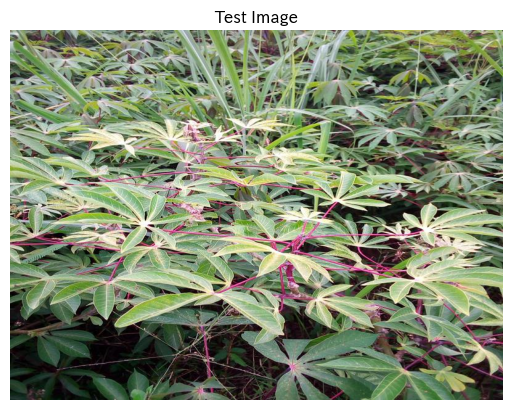

予測結果: 【 Cassava Mosaic Disease (CMD: モザイク病) 】
（参考）各クラスの出力スコア: [-2.896151  -2.627264   1.201974   2.8029547 -0.6936012]


In [ ]:
# ラベルと病気名の対応表
disease_map = {
    0: "Cassava Bacterial Blight (CBB: 細菌性胴枯病)",
    1: "Cassava Brown Streak Disease (CBSD: 褐条病)",
    2: "Cassava Green Mottle (CGM: 緑斑モザイク病)",
    3: "Cassava Mosaic Disease (CMD: モザイク病)",
    4: "Healthy (健康)"
}

# テスト画像の読み込みと表示
test_image_path = './cassava-data/test_images/2216849948.jpg'

# 画像の確認
img = Image.open(test_image_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.title("Test Image")
plt.show()

# 推論の実行

# モデルを「テストモード」に切り替える
model.eval()

# 画像を学習時と同じルールで加工（256x256にしてTensor化）
input_tensor = my_transform(img)

# バッチサイズの次元を追加（[3, 256, 256] -> [1, 3, 256, 256]）
input_tensor = input_tensor.unsqueeze(0).to(device)

# 勾配計算をストップ
with torch.no_grad():
    # 予測
    outputs = model(input_tensor)
    # 予測したクラスのインデックスを取得
    _, predicted_idx = torch.max(outputs, 1) # 1で列方向

# Tensorから数字に取り出す
final_prediction = predicted_idx.item()

print(f"予測結果: 【 {disease_map[final_prediction]} 】")

# 参考：それぞれの病気に対するAIのナマの自信度（スコア）
print(f"（参考）各クラスの出力スコア: {outputs[0].cpu().numpy()}")

### 画像拡張で実装

In [ ]:
# シードを固定
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

# トレインデータ用の処理（学習データの拡張）
train_transform = transforms.Compose([
    # 画像の一部をランダムに切り抜き、256×256にリサイズ
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),

    # 50% の確率で画像を左右反転
    transforms.RandomHorizontalFlip(p=0.5),

    # 50% の確率で画像を上下反転
    transforms.RandomVerticalFlip(p=0.5),

    # 最大45度の範囲で画像をランダムに回転
    transforms.RandomRotation(degrees=15),

    # 明るさとコントラストをランダムに±20% 変更
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # 画像をTensorに変換
    transforms.ToTensor(),
])


# 検証データ用の処理（テストデータはサイズの統一とTensor変換のみ）
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [ ]:
df = pd.read_csv('./cassava-data/train.csv')

# トレインデータと検証データに分割
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# トレインデータ用の処理を実装
train_dataset = CassavaDataset(
    dataframe=train_df,
    image_dir='./cassava-data/train_images',
    transform=train_transform # 画像データの拡張処理
)

# 検証データ用の処理を実装
val_dataset = CassavaDataset(
    dataframe=val_df,
    image_dir='./cassava-data/train_images',
    transform=test_transform # 変形を行わない処理
)

# DataLoader の作成
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    # モデルを学習モードに設定
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 今回のバッチのLossを足し合わせる
        running_loss += loss.item()
        # 予測ラベル（最大値のインデックス）を取得
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0) # 今回のバッチを足す
        correct += (predicted == labels).sum().item() # 正解した

    return running_loss / len(loader), correct / total

def validate_one_epoch(model, loader, criterion, device):
    # モデルをテストモードに設定
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # 勾配の計算を無効化
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total

# 学習の実行
num_epochs = 5
for epoch in range(num_epochs):
    # 学習フェーズ
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    # 検証フェーズ
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/5]
Train Loss: 0.8551, Train Acc: 0.6807
Val Loss: 0.7470, Val Acc: 0.6995
Epoch [2/5]
Train Loss: 0.8227, Train Acc: 0.6950
Val Loss: 0.6873, Val Acc: 0.7379
Epoch [3/5]
Train Loss: 0.7948, Train Acc: 0.7046
Val Loss: 0.7126, Val Acc: 0.7428
Epoch [4/5]
Train Loss: 0.7699, Train Acc: 0.7132
Val Loss: 0.6840, Val Acc: 0.7477
Epoch [5/5]
Train Loss: 0.7531, Train Acc: 0.7189
Val Loss: 0.6662, Val Acc: 0.7547


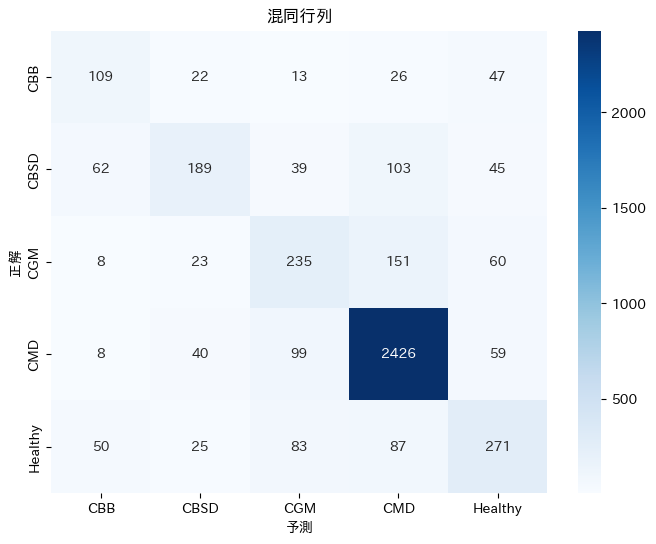


--- クラスごとの成績 ---
              precision    recall  f1-score   support

         CBB       0.46      0.50      0.48       217
        CBSD       0.63      0.43      0.51       438
         CGM       0.50      0.49      0.50       477
         CMD       0.87      0.92      0.89      2632
     Healthy       0.56      0.53      0.54       516

    accuracy                           0.75      4280
   macro avg       0.60      0.57      0.59      4280
weighted avg       0.75      0.75      0.75      4280



In [ ]:
# 病気名のリスト
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

def evaluate_model_details(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    # 検証データをすべて回して、予測と正解をリストに貯める
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1) # 予測のインデックス（0〜4）取得

            # GPU上のデータをCPUに戻し、NumPy配列にしてリストに追加
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 混同行列（Confusion Matrix）の作成
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    # ヒートマップ
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('予測')
    plt.ylabel('正解')
    plt.title('混同行列')
    plt.show()

    # Classification Report出力
    print("\n--- クラスごとの成績 ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# 実行
evaluate_model_details(model, val_loader, device)

本当の正解: CMD
AIの予測: CMD


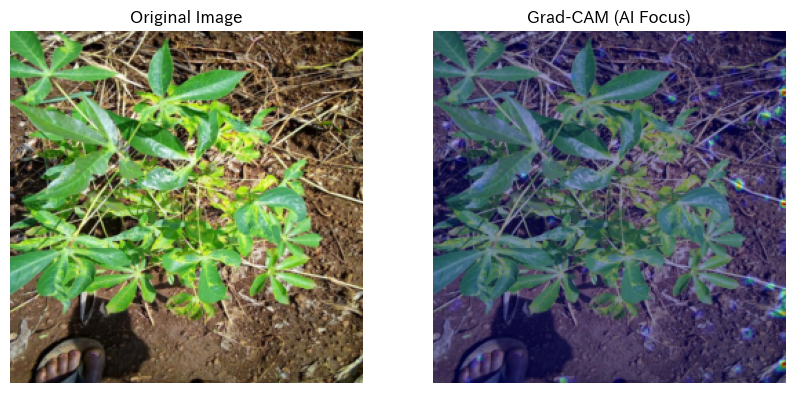

In [ ]:
def generate_gradcam(model, image_tensor, target_class, target_layer):
    """
    Grad-CAMのヒートマップを生成する関数
    """
    # 勾配を保存するための変数
    gradients = []
    def save_gradient(grad):
        gradients.append(grad)

    # 1. 順伝播
    model.eval()
    # 対象の層（conv3など）の出力（活性化）を取得できるようにフックを設定
    features = None
    # ターゲット層の出力を取得するための処理
    x = image_tensor
    # 手動で順伝播を追い、ターゲット層の出力を保持する
    x = model.pool(F.relu(model.conv1(x)))
    x = model.pool(F.relu(model.conv2(x)))
    features = model.conv3(x) # 活性化関数(ReLU)の直前の値を使用
    features.register_hook(save_gradient)

    # 最終的な出力を得るために残りの層も計算
    output_features = model.pool(F.relu(features))
    output_features = output_features.view(-1, 64 * 32 * 32)
    output = model.fc2(F.relu(model.fc1(output_features)))

    # 2. 逆伝播
    model.zero_grad()
    # ターゲットクラスのスコアを取得
    score = output[0][target_class]
    # スコアを微分して勾配を計算
    score.backward()

    # 3. ヒートマップの合成
    # 保存した勾配を取得
    grads = gradients[0]
    # 各チャンネル（64枚）の勾配の平均を重みとする
    weights = torch.mean(grads, dim=(2, 3), keepdim=True)
    # 重みと特徴量を掛け合わせて合成
    cam = torch.sum(weights * features, dim=1).squeeze().cpu().detach().numpy()

    # ReLUを適用（正の影響のみ抽出）し、0-1に正規化
    cam = np.maximum(cam, 0)
    cam = cam / (np.max(cam) + 1e-10)
    # 元の画像サイズ(256x256)にリサイズ
    cam = cv2.resize(cam, (256, 256))

    return cam

def plot_gradcam(image_tensor, cam):
    """
    元の画像とヒートマップを重ねて表示する関数
    """
    # Tensorを画像に戻す
    img = image_tensor.squeeze().cpu().permute(1, 2, 0).numpy()

    # ヒートマップをカラーマップ（JET）に変換
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # 元の画像とヒートマップを合成（重み 0.5ずつ）
    result = heatmap * 0.4 + img * 0.6

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()

# 実行例：検証データの最初の1枚で試す
dataiter = iter(val_loader)
images, labels = next(dataiter)
idx = 0 # 0番目の画像
img_t = images[idx].unsqueeze(0).to(device)

# AIが予測したクラスに対してGrad-CAMを実行
model.eval()
with torch.no_grad():
    output = model(img_t)
    _, pred = torch.max(output, 1)

print(f"正解: {class_names[labels[idx]]}")
print(f"予測: {class_names[pred.item()]}")

# ヒートマップ生成
cam = generate_gradcam(model, img_t, pred.item(), model.conv3)
plot_gradcam(img_t, cam)

<h4>結果</h4>
正解率（actuary）はよく見えるが、もともとCMDが多いことで一見して精度が良く見えるだけの状態。<br>
とりあえずCMDを予測しておけばいいや、という傾向になってしまっている。

---

## Focal Loss

### Focal Lossとは…

<blockquote>
簡単なサンプルの影響を減らして、難しいサンプルを重視するために <b>クロスエントロピー損失に重み（調整係数）を掛ける手法。</b>
</blockquote>


計算式で表すと以下の形となる。

$Loss = -\alpha (1-p)^\gamma \log(p)$


#### 0. 前提としてクロスエントロピーCross Entropy Loss）の計算

$-log(p)$

* $p = 正解クラスの予測確率$ <br>

一番基本となる損失関数は、対数（$\log$）を使った上記の式


#### 1. 正解確率による調整パラメータ：γ

$(1 - p)^γ$

* $p = 正解クラスの予測確率$ <br>
* $γ= 調整パラメータ（通常は2くらい）$


**考え方…**
* 正解確率が高い場合は $(1 - p)^γ$ が小さくなるため、損失も小さくなる

  * $ 例：(1-0.9)^2 = 0.1^2 = 0.01 $

* 正解確率が低い場合は $(1 - p)^γ$ が大きくなるため、相対的に重視される（学習の影響が大きくなる）

  * $ 例：(1-0.1)^2 = 0.9^2 = 0.81 $

**なぜするのか：**
    
クロスエントロピー損失では簡単なデータも難しいデータも同じように扱うため、特にクラス不均衡の状況では簡単なサンプルに学習が偏ってしまうことがある。

<br>

#### 2. データ数による調整パラメータ：α

* $α(1 - p)^γ$

**考え方…**
* データ数が多いクラスの場合、αの値は小さくなる
* データ数が少ないクラスの場合、αの値は大きくなる

---

#### 【γとαの違いまとめ】

* γ（ガンマ）：予測確率による難易度調整のためのパラメータ
* α（アルファ）：データ数の不均衡調整のためのパラメータ


In [ ]:
# αの実装：データ数による調整パラメータ

# 学習データ内の各クラスの枚数をカウント
class_counts = train_df['label'].value_counts().sort_index().values
print(f'各クラスの枚数：{class_counts}')

# 枚数の「逆数」をとって重みを作成（枚数が少ないほど、重みが大きくなる）
weights = 1.0 / class_counts

# 重みの合計がクラス数になるように正規化
weights = weights / weights.sum() * len(class_counts)
print(f'計算された重み：{weights}')

# PyTorchのTensor型に変換し、GPUに送る
class_weights = torch.FloatTensor(weights).to(device)

各クラスの枚数：[  870  1751  1909 10526  2061]
計算された重み：[2.03469349 1.01095565 0.92728305 0.16817246 0.85889536]


In [ ]:
# セッション切れにより再定義

# csv 読み込み
df = pd.read_csv('./cassava-data/train.csv')

# Datasetクラス
class CassavaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['image_id']
        label = self.dataframe.iloc[idx]['label']
        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# 画像の加工ルール（256×256に揃えてTensorに変換）
my_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# DataLoaderの作成（バッチサイズを32に設定）
train_dataset = CassavaDataset(df, './cassava-data/train_images', transform=my_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #torch.Size([32, 3, 256, 256])

def train_one_epoch(model, loader, optimizer, criterion, device):
    # モデルを学習モードに設定
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 今回のバッチのLossを足し合わせる
        running_loss += loss.item()
        # 予測ラベル（最大値のインデックス）を取得
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0) # 今回のバッチを足す
        correct += (predicted == labels).sum().item() # 正解した

    return running_loss / len(loader), correct / total

def validate_one_epoch(model, loader, criterion, device):
    # モデルを評価モードに設定
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # 勾配の計算を無効化
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total

In [ ]:
# パラメータαの適用

model = SimpleCNN().to(device)

# Criterion を変更（CrossEntropyLossにクラス数で正規化した重みを渡す）
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    print(f'Epoch[{epoch+1}/{num_epochs}]')
    print(f'Train Loss; {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss; {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch[1/5]
Train Loss; 1.5633, Train Acc: 0.3519
Val Loss; 1.5336, Val Acc: 0.6075
Epoch[2/5]
Train Loss; 1.4448, Train Acc: 0.4390
Val Loss; 1.4904, Val Acc: 0.5549
Epoch[3/5]
Train Loss; 1.3764, Train Acc: 0.4819
Val Loss; 1.3562, Val Acc: 0.2421
Epoch[4/5]
Train Loss; 1.2981, Train Acc: 0.4891
Val Loss; 1.2689, Val Acc: 0.3764
Epoch[5/5]
Train Loss; 1.2067, Train Acc: 0.5117
Val Loss; 1.0950, Val Acc: 0.5423


In [ ]:
save_path_alpha = 'model_alpha_only_epoch5.pth'
torch.save(model.state_dict(), save_path_alpha)
print('重みデータのダウンロード')
files.download(save_path_alpha)

重みデータのダウンロード


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

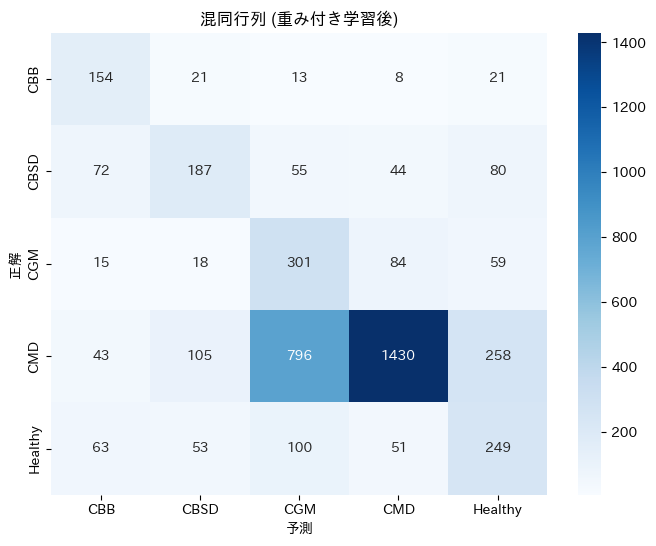


--- クラスごとの詳細な成績表 ---
              precision    recall  f1-score   support

         CBB       0.44      0.71      0.55       217
        CBSD       0.49      0.43      0.45       438
         CGM       0.24      0.63      0.35       477
         CMD       0.88      0.54      0.67      2632
     Healthy       0.37      0.48      0.42       516

    accuracy                           0.54      4280
   macro avg       0.49      0.56      0.49      4280
weighted avg       0.69      0.54      0.58      4280



In [ ]:
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

def evaluate_model_details(model, loader, device):
    model.eval() # テストモードに切り替え
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 混同行列
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('予測')
    plt.ylabel('正解')
    plt.title('混同行列 (重み付き学習後)')
    plt.show()

    # Classification Report
    print("\n--- クラスごとの詳細な成績表 ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model_details(model, val_loader, device)

In [ ]:
# 正解確率による調整パラメータ

# FocalLossの計算
class FocalLoss(nn.Module):

    def __init__(self, weight=None, gamma=2.0): # 調整パラメータγを2に設定
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    # inputs = 回答スコア, targets = 正解ラベル
    def forward(self, inputs, targets):
        # 1枚ごとのCrossEntropyLossを計算し、ce_loss_unweightedに32枚分のLossの配列を作成
        ce_loss_unweighted = F.cross_entropy(inputs, targets, reduction='none')

        # 正解の病気に対して何%の確率であるかを逆算
        pt = torch.exp(-ce_loss_unweighted) # ce_loss_unweighted = -log(p)

        # 重み(α)を適用したLoss
        ce_loss_weighted = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')

        # Focal Lossの適用(クロスエントロピー損失に重み（調整係数）を掛ける)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss_weighted

        # バッチ全体の平均
        return focal_loss.mean()

print('Focal_Lossの準備完了')

Focal_Lossの準備完了


In [ ]:
# Focal Loss

model = SimpleCNN().to(device)

# Criterion を変更（パラメータαとγを適用）
criterion = FocalLoss(weight=class_weights, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    print(f'Epoch[{epoch+1}/{num_epochs}]')
    print(f'Train Loss; {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss; {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch[1/5]
Train Loss; 0.5372, Train Acc: 0.2324
Val Loss; 0.5324, Val Acc: 0.6150
Epoch[2/5]
Train Loss; 0.5109, Train Acc: 0.2509
Val Loss; 0.4760, Val Acc: 0.1633
Epoch[3/5]
Train Loss; 0.4766, Train Acc: 0.2536
Val Loss; 0.4890, Val Acc: 0.2778
Epoch[4/5]
Train Loss; 0.4571, Train Acc: 0.3298
Val Loss; 0.4428, Val Acc: 0.3093
Epoch[5/5]
Train Loss; 0.4350, Train Acc: 0.3687
Val Loss; 0.4046, Val Acc: 0.4023


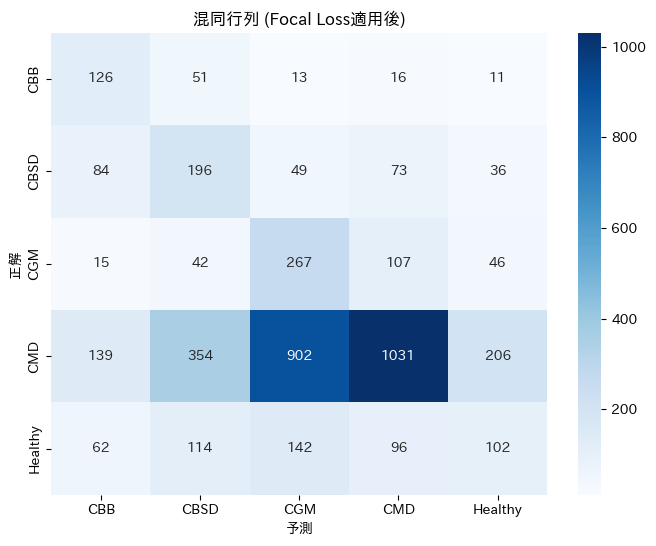


--- クラスごとの詳細な成績表 ---
              precision    recall  f1-score   support

         CBB       0.30      0.58      0.39       217
        CBSD       0.26      0.45      0.33       438
         CGM       0.19      0.56      0.29       477
         CMD       0.78      0.39      0.52      2632
     Healthy       0.25      0.20      0.22       516

    accuracy                           0.40      4280
   macro avg       0.36      0.44      0.35      4280
weighted avg       0.57      0.40      0.43      4280



In [ ]:
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

def evaluate_model_details(model, loader, device):
    model.eval() # テストモードに切り替え
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 混同行列
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('予測')
    plt.ylabel('正解')
    plt.title('混同行列 (Focal Loss適用後)')
    plt.show()

    # Classification Report
    print("\n--- クラスごとの詳細な成績表 ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model_details(model, val_loader, device)

#### 参考：最初のシンプルCNNによる予測

<blockquote>



--- クラスごとの成績 ---
<br>

    precision    recall    f1-score    support
    
    CBB       0.46      0.50      0.48       217
    CBSD       0.63      0.43      0.51       438
    CGM       0.50      0.49      0.50       477
    CMD       0.87      0.92      0.89      2632
    Healthy       0.56      0.53      0.54       516

    accuracy                           0.75      4280
    macro avg       0.60      0.57      0.59      4280
    weighted avg       0.75      0.75      0.75      4280


<blockquote>

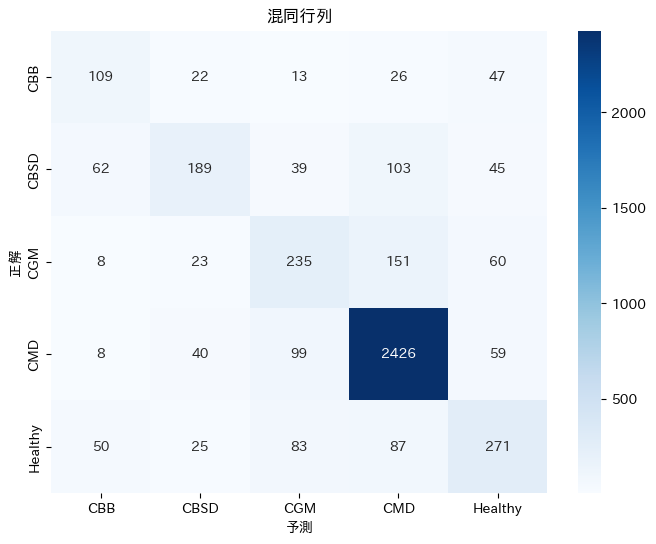

#### 結果：

* 結果として、ペナルティが効きすぎたため少ないデータであるCGMやCBSDを過剰にカバーしようとしてしまった。
* 徐々にCMD以外を拾おうと頑張って学習をしているが、ペナルティを気を使いすぎて予測が分散しただけになってしまった。
* 次回以降はペナルティを少し弱らせるためにパラメータチューニングの実行から必要になる想定。

#### 感想：

画像タスクはGPUをすぐに使ってしまうのでセッションがすぐに切れてしまう！((´；ω；`)

シンプル構造だったので今回モデルを学習させる時間はそこまでかからなかったけど、突き詰めると大変そう＼(＾o＾)／

#### 次回の目標
* ペナルティの影響が強すぎたためパラメータチューニングによりペナルティの調整をする
* epochや調整した結果がどのような作用をするか知る
* 自力モデルで画像タスクの根本を徹底的に理解する
* シンプルCNNを経て高精度モデル（事前学習済みモデルやファインチューニング、転移学習など）でどのような結果が出るか試す



In [ ]:
save_path_alpha = 'model_focal_loss_epoch5.pth'
torch.save(model.state_dict(), save_path_alpha)
print('重みデータのダウンロード')
files.download(save_path_alpha)

重みデータのダウンロード


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 途中経過から再開
model = SimpleCNN().to(device)
model.load_state_dict(torch.load(model_focal_loss_epoch5.pth, map_location=device))